In [9]:
import torch
from typing import Dict, Any, Tuple, List


from model_ranking import get_unsupervised_loader
from model_ranking import (
    SelfTrainingDataConfig,
    Pytorch3DUnetModelConfig,
    ModelConsisPseudoLabelerConfig,
)
from model_ranking.datasets import (
    get_loaders,
)
from model_ranking import ModelConsistencyPatchWisePseudoLabeler
from model_ranking import get_unsupervised_dataset
from pytorch3dunet.unet3d.model import (
    get_model,  # pyright: ignore[reportUnknownVariableType]
)
from pytorch3dunet.unet3d.utils import (
    load_checkpoint,  # pyright: ignore[reportUnknownVariableType]
)

In [10]:
import matplotlib.pyplot as plt
# Visualize the first sample from each batch
def visualize_samples(sample: Tuple[torch.Tensor, torch.Tensor]):
    xu1, xu2 = sample
    _ = plt.figure(figsize=(10, 5))
    _ = plt.subplot(1, 2, 1)
    _ = plt.imshow(xu1[0].detach().cpu().numpy().squeeze(), cmap='gray') #pyright: ignore[reportUnknownArgumentType]
    _ = plt.axis('off')
    _ = plt.subplot(1, 2, 2)
    _ = plt.imshow(xu2[0].detach().cpu().numpy().squeeze(), cmap='gray') #pyright: ignore[reportUnknownArgumentType]
    _ = plt.axis('off')

    plt.show()

# Configs

In [22]:
data_config: Dict[str, Any] = {
    "unsupervised_train_paths": ["/scratch/talks/data/EPFL/train.h5"],
    "unsupervised_val_paths": ["/scratch/talks/data/EPFL/val.h5"],
    "patch_shape": [1, 256, 256],
    "supervised_train_paths": None,
    "supervised_val_paths": None,
    "raw_key": "raw",
    "raw_key_supervised": None,
    "label_key": None,
    "batch_size": 2,
    "num_workers": 8,
    "n_samples_train": None,
    "n_samples_val": None
}

data_cfg = SelfTrainingDataConfig.model_validate(data_config)

In [23]:
pseudo_labeler_config: Dict[str, Any] = {
    "name": "model_consistency",
    "consistency_threshold": 0.9,
    "seg_params": {
        "name": "semantic"
    },
    "consistency_metric": {
        "name": "EI",
        "threshold": 0.5,
        "save_key": None,
        "save_mask": None,
        "mask_threshold": 0.5,
        "overwrite_score": None,
    },
    "perturbed_model_config": {
        "name": "UNet2d_as3d",
        "in_channels": 1,
        "out_channels": 1,
        "layer_order": "bcr",
        "f_maps": 32,
        "final_sigmoid": True,
        "feature_return": False,
        "is_segmentation": True,
        "feature_perturbation": {
            "layers": [0],
            "random_seed": 42,
            "name": "DropOutPerturbation",
            "drop_rate": 0.2,
            "spatial_dropout": True,
        }
    }
}
pseudo_labeler_cfg = ModelConsisPseudoLabelerConfig.model_validate(pseudo_labeler_config)

In [24]:
model_config : Dict[str, Any] = {
    "name": "UNet2d_as3d",
    "in_channels": 1,
    "out_channels": 1,
    "layer_order": "bcr",
    "f_maps": 32,
    "final_sigmoid": True,
    "feature_return": False,
    "is_segmentation": True,
    "feature_perturbation": None
}
model_cfg = Pytorch3DUnetModelConfig.model_validate(model_config)

# Unsupervised Dataloaders

In [5]:
unsupervised_train_loader_v1 = get_unsupervised_loader(
    data_cfg.unsupervised_train_paths,
    data_cfg.raw_key,
    data_cfg.patch_shape,
    data_cfg.batch_size,
    num_workers=data_cfg.num_workers,
    n_samples=data_cfg.n_samples_train,
    shuffle=False,
)

In [6]:
unsupervised_train_loader_v2 = get_unsupervised_loader(
    data_cfg.unsupervised_train_paths,
    data_cfg.raw_key,
    data_cfg.patch_shape,
    data_cfg.batch_size,
    num_workers=data_cfg.num_workers,
    n_samples=data_cfg.n_samples_train,
    shuffle=False,
)

In [8]:
unsupervised_dataset_v1 = get_unsupervised_dataset(
    data_cfg.unsupervised_train_paths,
    data_cfg.raw_key,
    data_cfg.patch_shape,
)

In [42]:
unsupervised_dataset_v2 = get_unsupervised_dataset(
    data_cfg.unsupervised_train_paths,
    data_cfg.raw_key,
    data_cfg.patch_shape,
)

In [43]:
print("Dataset length v1:", len(unsupervised_dataset_v1))
print("Dataset length v2:", len(unsupervised_dataset_v2))

Dataset length v1: 773
Dataset length v2: 773


In [ ]:
from typing import List, Tuple
# Get the first 2 batches from the unsupervised_train_loader
batches_v1: List[Tuple[torch.Tensor, torch.Tensor]] = []
loader_iter_v1 = iter(unsupervised_train_loader_v1)
for _ in range(2):
    batches_v1.append(next(loader_iter_v1))
for batch_v1 in batches_v1:
    visualize_samples(batch_v1)

In [ ]:
batches_v2: List[Tuple[torch.Tensor, torch.Tensor]] = []
loader_iter_v2 = iter(unsupervised_train_loader_v2)
for _ in range(2):
    batches_v2.append(next(loader_iter_v2))
for batch_v2 in batches_v2:
    visualize_samples(batch_v2)

# HDF5Dataset

2025-06-10 11:03:56,519 [MainThread] INFO HDF5Dataset - Loading train set from: /scratch/talks/data/EPFL/train.h5...
2025-06-10 11:03:56,520 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 0.5509082674980164, global std: 0.11770268529653549
2025-06-10 11:03:56,782 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 32, 32)}
2025-06-10 11:03:56,799 [MainThread] INFO HDF5Dataset - Number of patches: 990


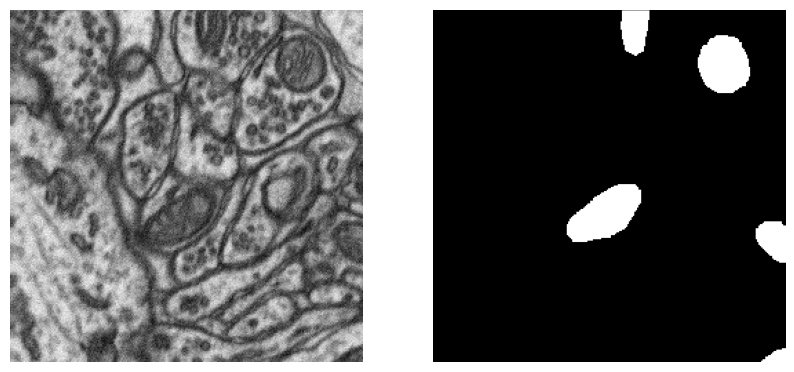

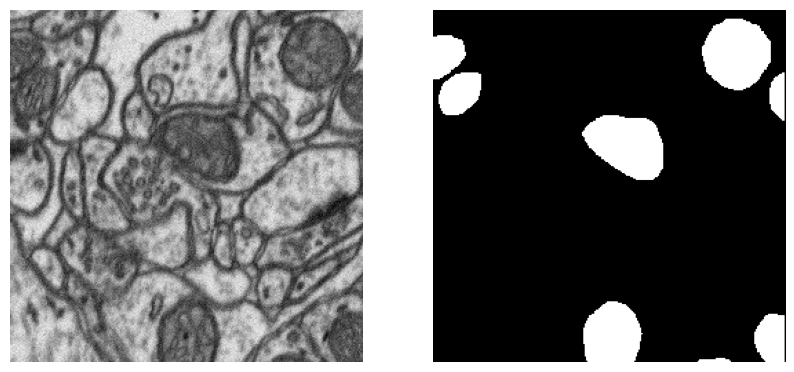

In [19]:
#from model_ranking import get_evaluation_loaders
from model_ranking import EPFLTargetConfig
target_cfg = EPFLTargetConfig()

for loader in get_loaders(
    target_cfg,
    phase="train",
    output_path=None,
    shuffle=False,
):
    batches_v1: List[Tuple[torch.Tensor, torch.Tensor]] = []
    loader_iter_v1 = iter(loader)
    for _ in range(2):
        batches_v1.append(next(loader_iter_v1))
    for batch_v1 in batches_v1:
        visualize_samples(batch_v1)

2025-06-10 11:03:23,744 [MainThread] INFO HDF5Dataset - Loading train set from: /scratch/talks/data/EPFL/train.h5...
2025-06-10 11:03:23,745 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 0.5509082674980164, global std: 0.11770268529653549
2025-06-10 11:03:23,995 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 32, 32)}
2025-06-10 11:03:24,009 [MainThread] INFO HDF5Dataset - Number of patches: 990


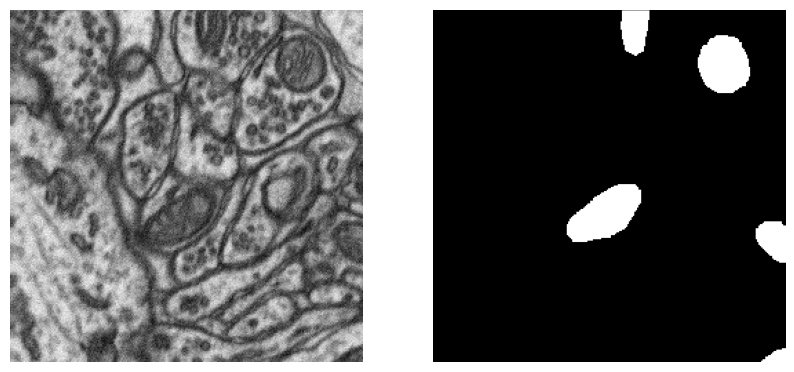

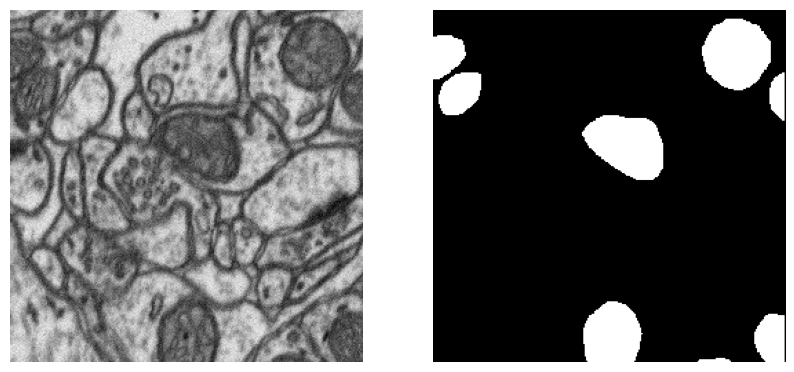

In [16]:
from model_ranking import EPFLTargetConfig
target_cfg = EPFLTargetConfig()

for loader in get_loaders(
    target_cfg,
    phase="train",
    output_path=None,
    shuffle=False,
):
    batches_v2: List[Tuple[torch.Tensor, torch.Tensor]] = []
    loader_iter_v2 = iter(loader)
    for _ in range(2):
        batches_v2.append(next(loader_iter_v2))
    # Visualize the first sample from each batch
    for batch_v2 in batches_v2:
        visualize_samples(batch_v2)

# Pseudo Labeler

In [2]:
import numpy as np
from model_ranking.datasets import get_datasets
from model_ranking import EPFLTargetConfig

INFO: P [MainThread] 2025-06-10 15:04:39,283 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [3]:
save_path = "/g/kreshuk/talks/model_ranking/scripts/tests/test_accepted_patches.npz"
datasets, loader_config = get_datasets(
    EPFLTargetConfig(),
    phase="train",
    output_path=None,
)
for dataset in datasets:
    selected_ids = np.load(save_path)["accepted_ids"]
    scores = np.load(save_path)["consis_scores"]
    print("Dataset length:", len(dataset))
    print("Selected IDs length:", len(selected_ids))
    print("Scores length:", len(scores))
    print(scores[:5])

2025-06-10 15:04:42,820 [MainThread] INFO HDF5Dataset - Loading train set from: /scratch/talks/data/EPFL/train.h5...
2025-06-10 15:04:42,821 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 0.5509082674980164, global std: 0.11770268529653549
2025-06-10 15:04:43,116 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 32, 32)}
2025-06-10 15:04:43,318 [MainThread] INFO HDF5Dataset - Number of patches: 990
Dataset length: 990
Selected IDs length: 959
Scores length: 990
[0.82328081 0.77594453 0.84693927 0.85353714 0.8711381 ]


In [19]:
proportion_accepted = len(selected_ids) / len(dataset)
print(f"Proportion of accepted patches: {proportion_accepted:.3f}")

Proportion of accepted patches: 0.969


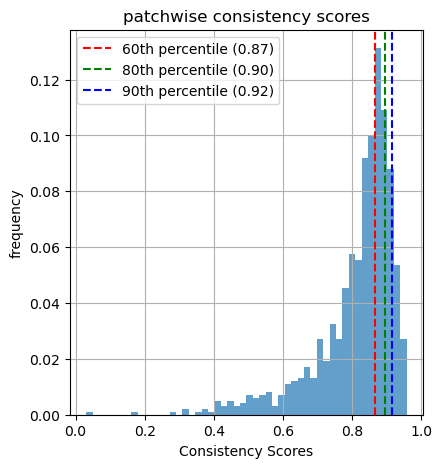

In [17]:
import matplotlib.pyplot as plt
_ = plt.figure(figsize=(10, 5))
_ = plt.subplot(1, 2, 1)
_ = plt.hist(scores, bins=50, weights=np.ones(len(scores)) / len(scores), alpha=0.7)
for p, c in zip([60, 80, 90], ['r', 'g', 'b']):
    perc = np.percentile(scores, p)
    _ = plt.axvline(perc, linestyle='--', color=c, label=f'{p}th percentile ({perc:.2f})')

plt.grid()
_ = plt.title("patchwise consistency scores")
_ = plt.xlabel('Consistency Scores')
_ = plt.ylabel('frequency')
_ = plt.legend()
plt.show()